In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Base API URL
base_url = "https://api.nobelprize.org/2.1/nobelPrizes"

In [2]:
# Parameters for the API request
params = {
    "nobelPrizeYear": 1901, # starting year (starts 1901)
    "yearTo": 2025,        # up to current year (2025)
    "sort": "asc",
    "format": "json",
    "limit": 1026 # can adjust as needed (Max as of 2025 is 1026)
}

In [3]:
# Make the request
response = requests.get(base_url, params=params)
data = response.json()

In [4]:
# Flatten the structure for DataFrame use
records = []
for prize in data["nobelPrizes"]:
    year = prize.get("awardYear")
    category = prize["category"]["en"]
    prize_amount = prize.get("prizeAmount")
    prize_amount_adj = prize.get("prizeAmountAdjusted")
    date_awarded = prize.get("dateAwarded")
    top_motivation = prize.get("topMotivation", {}).get("en", None)
    
    for laureate in prize.get("laureates", []):
        laureate_name = laureate.get("knownName", {}).get("en")
        motivation = laureate.get("motivation", {}).get("en", None)
        portion = laureate.get("portion", None)
        org = laureate.get("organization", {}).get("orgName", {}).get("en", None)

        records.append({
            "year": year,
            "category": category,
            "laureate": laureate_name,
            "organization": org,
            "motivation": motivation or top_motivation,
            "portion": portion,
            "prize_amount": prize_amount,
            "prize_amount_adjusted": prize_amount_adj,
            "date_awarded": date_awarded
        })

In [5]:
# Create DataFrame and inspect
df = pd.DataFrame(records)
print(df.head())
print(df.shape)
print(df.tail())

df.to_csv("nobel_prizes_original.csv", index=False)

   year    category                laureate organization  \
0  1901   Chemistry  Jacobus H. van 't Hoff         None   
1  1901  Literature         Sully Prudhomme         None   
2  1901       Peace            Henry Dunant         None   
3  1901       Peace          Frédéric Passy         None   
4  1901     Physics  Wilhelm Conrad Röntgen         None   

                                          motivation portion  prize_amount  \
0  in recognition of the extraordinary services h...       1        150782   
1  in special recognition of his poetic compositi...       1        150782   
2  for his humanitarian efforts to help wounded s...     1/2        150782   
3  for his lifelong work for international peace ...     1/2        150782   
4  in recognition of the extraordinary services h...       1        150782   

   prize_amount_adjusted date_awarded  
0               10833458   1901-11-12  
1               10833458   1901-11-14  
2               10833458   1901-12-10  
3         

In [6]:
# Perform transformations to make unique

# Transforming date_awarded to datetime
df['date_awarded'] = pd.to_datetime(df['date_awarded'])

# Create dummy variables for the 'category' column
category_dummies = pd.get_dummies(df['category'], prefix='category')

# Combine with original dataframe
df_with_dummies = pd.concat([df, category_dummies], axis=1)

# The following code can be used to drop the original 'category' column to avoid multicollinearity
# df_with_dummies = df_with_dummies.drop(columns=['category'])

# print(df_with_dummies.head())

In [7]:
# further transformations to help avoid bimodal distributions in analysis

# Check all unique portion values, these would affect the prize amount because it is split among laureates
#print(df['portion'].unique())
# ['1' '1/2' '1/4' '1/3']

# Create dummy variables for the portion column
portion_dummies = pd.get_dummies(df['portion'], prefix='portion')

# Merge into the main DataFrame
df_with_dummies = pd.concat([df, portion_dummies], axis=1)

# print(df_with_dummies.head())



In [8]:
# Combine dummies with the main DataFrame
df_ready = pd.concat([df, category_dummies, portion_dummies], axis=1)

# print(df_ready.head())


In [9]:
df_ready.to_csv("nobel_prizes_novel.csv", index=False)

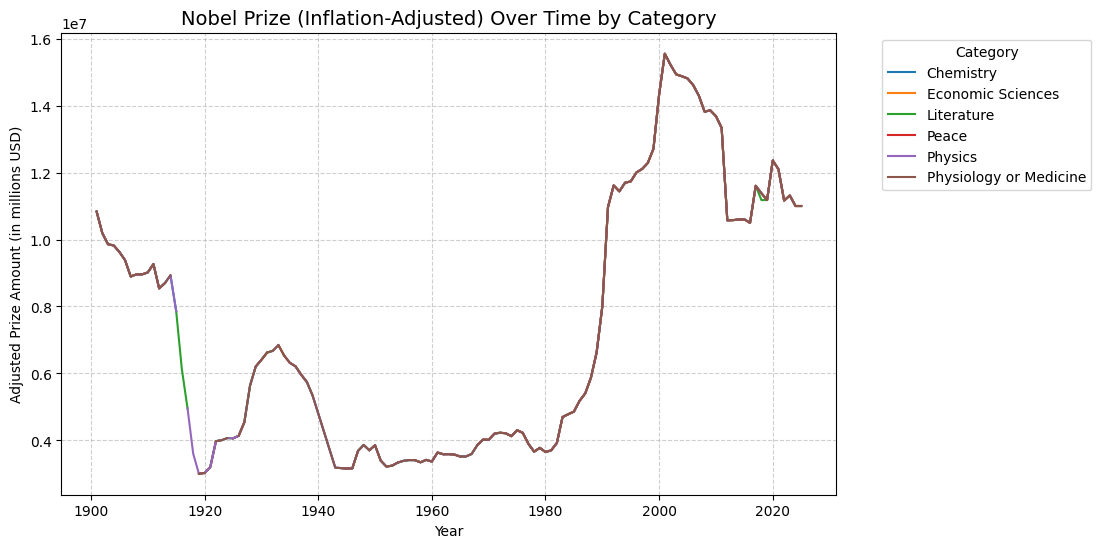

In [10]:
# BEGIN EDA

# Timeseries showing adjusted prize amounts over time, sorted by category

df['year'] = pd.to_numeric(df['year'], errors='coerce')

# Group by year and category, take the mean adjusted prize (handles multiple laureates)
grouped = df.groupby(['year', 'category'])['prize_amount_adjusted'].mean().reset_index()

# Pivot for easier plotting
pivot_df = grouped.pivot(index='year', columns='category', values='prize_amount_adjusted')

# --- Plot ---
plt.figure(figsize=(10, 6))
pivot_df.plot(ax=plt.gca())

plt.title('Nobel Prize (Inflation-Adjusted) Over Time by Category', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Adjusted Prize Amount (in millions USD)')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

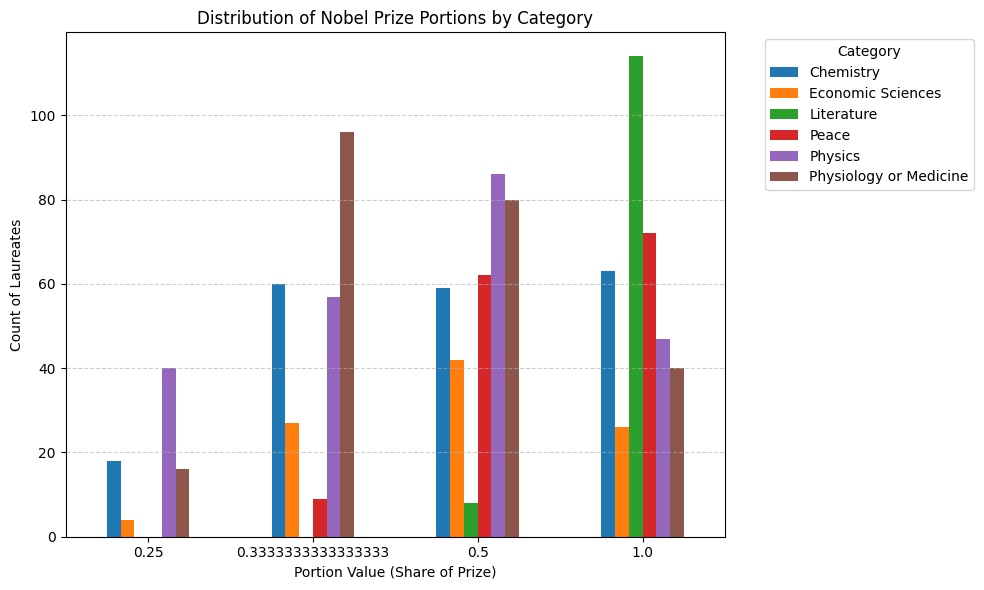

In [ ]:
# Density plot of portion values by category across all years
import matplotlib.pyplot as plt

# Count how many times each portion_value appears per category
portion_counts = (
    df.groupby(['category', 'portion_value'])
      .size()
      .reset_index(name='count')
)

# Pivot for easier plotting
pivot_counts = portion_counts.pivot(index='portion_value', columns='category', values='count').fillna(0)

# Plot side-by-side bars
pivot_counts.plot(kind='bar', figsize=(10,6))

plt.title('Distribution of Nobel Prize Portions by Category')
plt.xlabel('Portion Value (Share of Prize)')
plt.ylabel('Count of Laureates')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



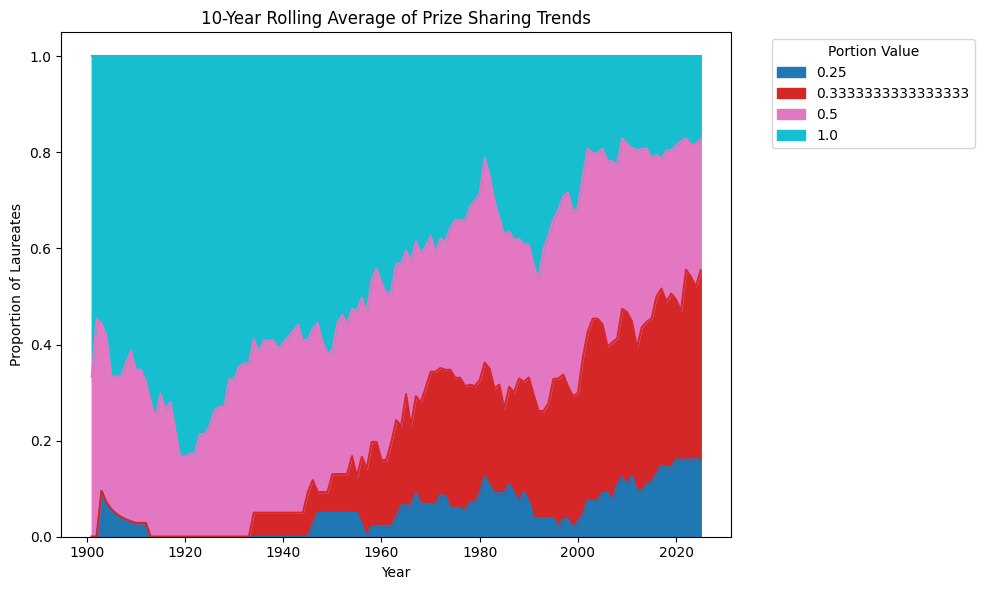

In [ ]:
# Count laureates by year and portion_value
portion_year = (
    df.groupby(['year', 'portion_value'])
      .size()
      .reset_index(name='count')
)

# Compute the share of each portion per year
portion_year['share'] = (
    portion_year.groupby('year')['count']
    .transform(lambda x: x / x.sum())
)

portion_trend = (
    portion_year.pivot(index='year', columns='portion_value', values='share')
    .fillna(0)
)

# use 10 year rolling average to make trends clearer
portion_trend_rolling = portion_trend.rolling(10, min_periods=1).mean()
portion_trend_rolling.plot(kind='area', stacked=True, figsize=(10,6), colormap='tab10')
plt.title('10-Year Rolling Average of Prize Sharing Trends')
plt.xlabel('Year')
plt.ylabel('Proportion of Laureates')
plt.legend(title='Portion Value', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

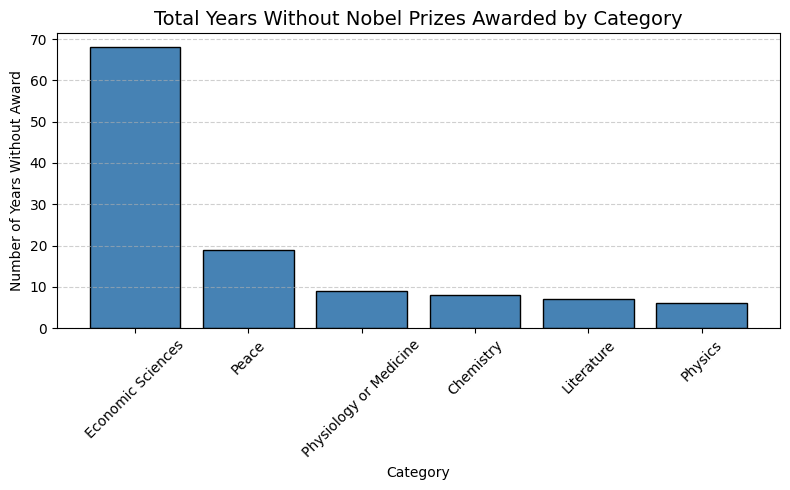

In [ ]:
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# Get all possible (year, category) combinations
all_years = range(int(df['year'].min()), int(df['year'].max()) + 1)
categories = df['category'].unique()

grid = pd.MultiIndex.from_product([all_years, categories], names=['year', 'category'])
grid = pd.DataFrame(index=grid).reset_index()

# Mark whether each (year, category) had an award
grid['awarded'] = grid.apply(
    lambda row: ((df['year'] == row['year']) & (df['category'] == row['category'])).any(),
    axis=1
)

# Count how many years *did not* have an award per category
missing_counts = (
    grid[~grid['awarded']]
    .groupby('category')
    .size()
    .reset_index(name='missing_years')
    .sort_values('missing_years', ascending=False)
)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(missing_counts['category'], missing_counts['missing_years'], color='steelblue', edgecolor='black')

plt.title('Total Years Without Nobel Prizes Awarded by Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Number of Years Without Award')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
